# Proyecto 03 — Análisis de Microestructura de Mercado
**Curso:** Trading Cuantitativo · MFQ 1er Bimestre 2026  
**Referencia:** Cont, Kukanov & Stoikov (2014); Roll (1984); Avellaneda & Stoikov (2008)  

---
## Estructura del notebook
1. Instalación y configuración  
2. Generación de datos sintéticos calibrados (Hawkes + GBM)  
3. Reconstrucción y limpieza del Order Book L2  
4. Análisis de spreads: Quoted vs Effective  
5. Profundidad del book por nivel  
6. Patrones intradiarios de volatilidad y spread (U-shape)  
7. Order Flow Imbalance (OFI)  
8. Descomposición del spread (modelo Roll)  
9. Exportación de resultados  

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 1 — Instalación de dependencias
# Ejecutar solo la primera vez
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys

pkgs = ['numpy', 'pandas', 'scipy', 'matplotlib', 'seaborn', 'statsmodels', 'pyarrow']
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], check=False)

print('✓ Dependencias OK')

✓ Dependencias OK


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 2 — Imports y configuración global
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# ── Semilla global para reproducibilidad ──────────────────────────────────────
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# ── Parámetros del activo ─────────────────────────────────────────────────────
S0          = 100.0          # Precio inicial mid ($)
SIGMA_ANNUAL= 0.25           # Volatilidad anual (25%)
TICK        = 0.01           # Tamaño mínimo de tick ($)
LOT_SIZE    = 100            # Tamaño mínimo de orden (acciones)

# ── Sesión de trading ─────────────────────────────────────────────────────────
SECONDS_IN_SESSION = 23_400  # 9:30 – 16:00 = 6.5 h = 23 400 s
DT          = 1.0            # Resolución temporal: 1 segundo
N_STEPS     = SECONDS_IN_SESSION  # 23 400 snapshots
N_LEVELS    = 5              # Niveles del order book

# ── Parámetros del proceso de Hawkes (calibrado con Cont et al. 2010) ─────────
# 6 procesos: bid_add, bid_cancel, ask_add, ask_cancel, trade_buy, trade_sell
HAWKES_MU   = np.array([2.0, 1.5, 2.0, 1.5, 0.5, 0.5])   # Intensidad base (eventos/s)
HAWKES_ALPHA= np.array([0.3, 0.2, 0.3, 0.2, 0.1, 0.1])   # Excitación entre procesos
HAWKES_BETA = np.array([1.0, 1.0, 1.0, 1.0, 0.8, 0.8])   # Decaimiento exponencial

# ── Estilos de gráficas ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0b0e14',
    'axes.facecolor'  : '#111520',
    'axes.edgecolor'  : '#3a3f52',
    'axes.labelcolor' : '#e8eaf0',
    'text.color'      : '#e8eaf0',
    'xtick.color'     : '#7a8099',
    'ytick.color'     : '#7a8099',
    'grid.color'      : '#1e2333',
    'grid.linestyle'  : '--',
    'grid.alpha'      : 0.6,
    'legend.facecolor': '#161b28',
    'legend.edgecolor': '#3a3f52',
    'figure.dpi'      : 110,
})
COLORS = {'teal': '#34d399', 'blue': '#4f8cff', 'gold': '#f5c842',
          'red': '#f87171', 'purple': '#a78bfa', 'muted': '#7a8099'}

print(f'✓ Config cargada | N_steps={N_STEPS:,} | Tick={TICK} | S0={S0}')

✓ Config cargada | N_steps=23,400 | Tick=0.01 | S0=100.0


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 3 — Generación de datos sintéticos
#
# Mid-price: GBM discreto   dS = σ·S·dW  (drift=0, MM neutral)
# Intensidades Hawkes       λ_i(t) = μ_i + α_i·Σ exp(-β_i·(t-t_j))
# Book L2: spread y profundidad generados condicionalmente al régimen
# ─────────────────────────────────────────────────────────────────────────────

def simulate_gbm_midprice(S0, sigma_annual, n_steps, dt=1.0, rng=None):
    """GBM discreto en tiempo continuo.
    sigma_s = sigma_annual / sqrt(252*23400) → volatilidad por segundo"""
    rng = rng or np.random.default_rng()
    sigma_s = sigma_annual / np.sqrt(252 * 23_400)  # ~0.0001030 $/s^0.5
    dW = rng.normal(0, np.sqrt(dt), n_steps)
    log_returns = -0.5 * sigma_s**2 * dt + sigma_s * dW
    prices = S0 * np.exp(np.cumsum(log_returns))
    prices = np.insert(prices[:-1], 0, S0)          # alinear con t=0..N-1
    return prices


def simulate_hawkes_intensity(mu, alpha, beta, n_steps, dt=1.0, rng=None):
    """Simulación univariada del proceso de Hawkes por thinning (Ogata 1981).
    Retorna: (timestamps, intensidades discretizadas por segundo)"""
    rng = rng or np.random.default_rng()
    times = []
    t = 0.0
    T_max = n_steps * dt
    while t < T_max:
        # Cota superior de la intensidad (evaluada en t actual)
        phi = sum(alpha * np.exp(-beta * (t - s)) for s in times[-50:]) if times else 0.0
        lambda_bar = mu + phi
        t += rng.exponential(1.0 / max(lambda_bar, 1e-9))
        if t >= T_max:
            break
        # Thinning: aceptar con probabilidad λ(t)/λ_bar
        phi_t = sum(alpha * np.exp(-beta * (t - s)) for s in times[-50:]) if times else 0.0
        lam_t = mu + phi_t
        if rng.uniform() <= lam_t / lambda_bar:
            times.append(t)
    # Discretizar a resolución 1s
    counts = np.zeros(n_steps)
    for s in times:
        idx = min(int(s / dt), n_steps - 1)
        counts[idx] += 1
    return np.array(times), counts


def build_synthetic_lob(mid_prices, n_steps, n_levels, tick, rng):
    """Construye snapshots del LOB L2 (5 niveles) condicionalmente al mid-price.
    
    Lógica:
    - Quoted spread base ~ |N(0.02, 0.01)|, mínimo 1 tick
    - Profundidad nivel k ~ Poisson(λ_k) donde λ_k = 10/k (perfil decreciente)
    - Volumen nivel k ~ Pareto(shape=1.5) * LOT_SIZE
    - U-shape intradiario: mayor spread al abrir/cerrar (minutos 0–60, 330–390)
    """
    # U-shape: factor de spread intradiario (segundos → minuto)
    t_rel = np.linspace(0, 1, n_steps)  # 0=apertura, 1=cierre
    ushape = 1.5 * (t_rel**2 - t_rel + 0.35)  # parabólica con mínimo en t=0.5
    ushape = (ushape - ushape.min()) / (ushape.max() - ushape.min()) * 0.8 + 0.6

    bids   = np.zeros((n_steps, n_levels))
    asks   = np.zeros((n_steps, n_levels))
    bid_v  = np.zeros((n_steps, n_levels))
    ask_v  = np.zeros((n_steps, n_levels))

    base_spread_raw = np.abs(rng.normal(0.02, 0.008, n_steps))
    base_spread = np.maximum(np.round(base_spread_raw * ushape / tick) * tick, tick)
    half_spread = base_spread / 2

    for lvl in range(n_levels):
        lvl_offset = lvl * tick  # precio empeora con cada nivel
        bids[:, lvl] = np.round((mid_prices - half_spread - lvl_offset) / tick) * tick
        asks[:, lvl] = np.round((mid_prices + half_spread + lvl_offset) / tick) * tick
        # Volumen: distribución Pareto truncada, mayor en nivel 1
        scale = max(10 - lvl * 1.5, 2)
        vol_raw = rng.pareto(1.5, n_steps) * scale * LOT_SIZE
        vol_clipped = np.clip(vol_raw, LOT_SIZE, 50 * LOT_SIZE).astype(int)
        # Redondear a múltiplos de LOT_SIZE
        bid_v[:, lvl] = (vol_clipped // LOT_SIZE) * LOT_SIZE
        ask_v[:, lvl] = ((vol_clipped + rng.integers(-2, 3, n_steps) * LOT_SIZE) // LOT_SIZE) * LOT_SIZE
        ask_v[:, lvl] = np.maximum(ask_v[:, lvl], LOT_SIZE)

    # Reconstruir timestamps (sesión 9:30–16:00)
    session_start = pd.Timestamp('2025-01-15 09:30:00')
    timestamps = pd.date_range(session_start, periods=n_steps, freq='1s')

    df = pd.DataFrame(index=timestamps)
    df['mid_price'] = mid_prices
    df['base_spread'] = base_spread
    for lvl in range(n_levels):
        df[f'bid_{lvl+1}'] = bids[:, lvl]
        df[f'ask_{lvl+1}'] = asks[:, lvl]
        df[f'bid_vol_{lvl+1}'] = bid_v[:, lvl]
        df[f'ask_vol_{lvl+1}'] = ask_v[:, lvl]
    return df


# ── Ejecutar simulación ───────────────────────────────────────────────────────
print('Simulando mid-price (GBM)...')
mid_prices = simulate_gbm_midprice(S0, SIGMA_ANNUAL, N_STEPS, DT, rng)

print('Simulando procesos de Hawkes (6 procesos)...')
hawkes_results = {}
process_names  = ['bid_add', 'bid_cancel', 'ask_add', 'ask_cancel', 'trade_buy', 'trade_sell']
for i, name in enumerate(process_names):
    _, counts = simulate_hawkes_intensity(
        HAWKES_MU[i], HAWKES_ALPHA[i], HAWKES_BETA[i], N_STEPS, DT, rng)
    hawkes_results[name] = counts

print('Construyendo LOB L2 (5 niveles)...')
lob = build_synthetic_lob(mid_prices, N_STEPS, N_LEVELS, TICK, rng)

# Agregar intensidades Hawkes al DataFrame
for name in process_names:
    lob[name] = hawkes_results[name]

print(f'✓ LOB generado: {lob.shape[0]:,} snapshots × {lob.shape[1]} columnas')
print(f'  Rango mid-price: [{lob.mid_price.min():.2f}, {lob.mid_price.max():.2f}]')
lob.head(3)

Simulando mid-price (GBM)...
Simulando procesos de Hawkes (6 procesos)...
Construyendo LOB L2 (5 niveles)...
✓ LOB generado: 23,400 snapshots × 28 columnas
  Rango mid-price: [97.97, 101.42]


,mid_price,base_spread,bid_1,ask_1,bid_vol_1,ask_vol_1,bid_2,ask_2,bid_vol_2,ask_vol_2,...,bid_5,ask_5,bid_vol_5,ask_vol_5,bid_add,bid_cancel,ask_add,ask_cancel,trade_buy,trade_sell
2025-01-15 09:30:00,100.000000,0.02,99.99,100.01,100.0,100.0,99.98,100.02,100.0,100.0,...,99.95,100.05,100.0,100.0,2.0,1.0,3.0,4.0,1.0,0.0
2025-01-15 09:30:01,100.003137,0.02,99.99,100.01,100.0,200.0,99.98,100.02,400.0,300.0,...,99.95,100.05,100.0,100.0,2.0,1.0,2.0,3.0,0.0,0.0
2025-01-15 09:30:02,99.992430,0.03,99.98,100.01,300.0,100.0,99.97,100.02,100.0,100.0,...,99.94,100.05,800.0,1000.0,6.0,1.0,4.0,2.0,1.0,0.0


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 4 — Limpieza y tratamiento de outliers
#
# Pasos:
#   A) Eliminar snapshots con bid1 >= ask1 (cruce inválido)
#   B) Winsorizar retornos del mid-price en p[0.5%, 99.5%] y RECONSTRUIR mid_price
#   C) Marcar outliers de spread con regla IQR × 3
#   D) Verificar integridad del book: precios decrecen hacia bid, crecen hacia ask
# ─────────────────────────────────────────────────────────────────────────────

lob_clean = lob.copy()
n_raw = len(lob_clean)

# A) Eliminar cruces (bid1 >= ask1)
crossed = lob_clean['bid_1'] >= lob_clean['ask_1']
lob_clean = lob_clean[~crossed]
print(f'[A] Snapshots cruzados eliminados: {crossed.sum()} ({crossed.mean()*100:.2f}%)')

# B) Winsorizar retornos del mid-price y RECONSTRUIR mid_price y bid/ask
# FIX: se aplica el clip y se reconstruye el precio a partir de retornos winzorizados
mid_returns = lob_clean['mid_price'].pct_change().dropna()
p_low  = mid_returns.quantile(0.005)
p_high = mid_returns.quantile(0.995)
n_outlier_ret = ((mid_returns < p_low) | (mid_returns > p_high)).sum()
print(f'[B] Retornos winzorizados: {n_outlier_ret} ({n_outlier_ret/len(mid_returns)*100:.2f}%)')
print(f'    Rango winsorizado: [{p_low*100:.4f}%, {p_high*100:.4f}%]')

# Aplicar clip y reconstruir mid_price
ret_winsored = mid_returns.clip(p_low, p_high)
# Primer valor del mid_price (no tiene retorno previo, se mantiene)
first_mid = lob_clean['mid_price'].iloc[0]
mid_reconstructed = first_mid * (1 + ret_winsored).cumprod()
# Alinear índices: el índice 0 no tiene retorno, lo rellenamos con first_mid
lob_clean['mid_price'] = mid_reconstructed.reindex(lob_clean.index).fillna(method='bfill')
lob_clean.loc[lob_clean.index[0], 'mid_price'] = first_mid

# Recalcular bid/ask nivel 1 manteniendo el half-spread original
half_spread_orig = lob_clean['base_spread'] / 2
lob_clean['bid_1'] = (lob_clean['mid_price'] - half_spread_orig).round(2)
lob_clean['ask_1'] = (lob_clean['mid_price'] + half_spread_orig).round(2)
# Recalcular niveles 2-5 a partir del nuevo mid
for lvl in range(2, N_LEVELS + 1):
    lvl_offset = (lvl - 1) * TICK
    lob_clean[f'bid_{lvl}'] = (lob_clean['mid_price'] - half_spread_orig - lvl_offset).round(2)
    lob_clean[f'ask_{lvl}'] = (lob_clean['mid_price'] + half_spread_orig + lvl_offset).round(2)
print(f'[B] mid_price y niveles bid/ask reconstruidos con retornos winzorizados.')

# C) Marcar outliers de spread (IQR × 3)
spread = lob_clean['ask_1'] - lob_clean['bid_1']
Q1, Q3 = spread.quantile(0.25), spread.quantile(0.75)
IQR    = Q3 - Q1
spread_outlier = (spread < Q1 - 3*IQR) | (spread > Q3 + 3*IQR)
lob_clean['spread_outlier'] = spread_outlier
print(f'[C] Outliers de spread (IQR×3): {spread_outlier.sum()} ({spread_outlier.mean()*100:.2f}%)')

# D) Verificar monotonicidad del book
for lvl in range(1, N_LEVELS):
    invalid_bid = (lob_clean[f'bid_{lvl+1}'] >= lob_clean[f'bid_{lvl}']).sum()
    invalid_ask = (lob_clean[f'ask_{lvl+1}'] <= lob_clean[f'ask_{lvl}']).sum()
    if invalid_bid > 0 or invalid_ask > 0:
        print(f'[D] Nivel {lvl+1}: bid_inv={invalid_bid}, ask_inv={invalid_ask} → corrigiendo')
        lob_clean[f'bid_{lvl+1}'] = lob_clean[[f'bid_{k}' for k in range(1, lvl+2)]].min(axis=1) - TICK
        lob_clean[f'ask_{lvl+1}'] = lob_clean[[f'ask_{k}' for k in range(1, lvl+2)]].max(axis=1) + TICK

n_clean = len(lob_clean)
print(f'\n✓ Limpieza completa: {n_raw:,} → {n_clean:,} snapshots válidos ({n_clean/n_raw*100:.1f}% retenido)')


[A] Snapshots cruzados eliminados: 0 (0.00%)
[B] Retornos winzorizados: 234 (1.00%)
    Rango winsorizado: [-0.0264%, 0.0264%]
[B] mid_price y niveles bid/ask reconstruidos con retornos winzorizados.
[C] Outliers de spread (IQR×3): 7 (0.03%)

✓ Limpieza completa: 23,400 → 23,400 snapshots válidos (100.0% retenido)


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5 — Cálculo de Spreads: Quoted y Effective
#
# Quoted Spread (QS):   QS_t = Ask_{1,t} - Bid_{1,t}
#   Mide el costo de una round-trip instantánea.
#
# Effective Spread (ES): ES_t = 2 · D_t · (P_trade_t - Mid_t)
#   D_t ∈ {+1, -1} dirección del trade (Lee-Ready rule simplificada)
#   Captura el costo real pagado por el tomador de liquidez.
#   En datos sintéticos: P_trade se aproxima al ask (compra) o bid (venta).
#
# Realized Spread (RS):  RS_t = 2 · D_t · (P_trade_t - Mid_{t+τ})
#   τ = 5s, mide la ganancia real del proveedor de liquidez.
# ─────────────────────────────────────────────────────────────────────────────

TAU_SECONDS = 5  # horizonte para realized spread

lob_clean = lob_clean.copy()

# ── Quoted Spread ────────────────────────────────────────────────────────────
lob_clean['quoted_spread']      = lob_clean['ask_1'] - lob_clean['bid_1']
lob_clean['quoted_spread_bps']  = lob_clean['quoted_spread'] / lob_clean['mid_price'] * 1e4
lob_clean['relative_spread']    = lob_clean['quoted_spread'] / lob_clean['mid_price']

# ── Dirección del trade (Lee-Ready simplificado sobre datos sintéticos) ───────
# trade_buy > 0 → dirección compradora (+1), trade_sell > 0 → vendedora (-1)
lob_clean['trade_direction'] = np.where(
    lob_clean['trade_buy'] > lob_clean['trade_sell'], +1,
    np.where(lob_clean['trade_sell'] > lob_clean['trade_buy'], -1, 0)
)

# ── Precio de ejecución (síntesis: compra al ask1, venta al bid1) ─────────────
lob_clean['trade_price'] = np.where(
    lob_clean['trade_direction'] == +1, lob_clean['ask_1'],
    np.where(lob_clean['trade_direction'] == -1, lob_clean['bid_1'],
             lob_clean['mid_price'])  # sin trade → mid
)

# ── Effective Spread ─────────────────────────────────────────────────────────
has_trade = lob_clean['trade_direction'] != 0
lob_clean['effective_spread'] = np.nan
lob_clean.loc[has_trade, 'effective_spread'] = (
    2 * lob_clean.loc[has_trade, 'trade_direction'] *
    (lob_clean.loc[has_trade, 'trade_price'] - lob_clean.loc[has_trade, 'mid_price'])
)
lob_clean['effective_spread_bps'] = lob_clean['effective_spread'] / lob_clean['mid_price'] * 1e4

# ── Realized Spread (con mid-price desplazado τ=5s) ──────────────────────────
lob_clean['mid_future'] = lob_clean['mid_price'].shift(-TAU_SECONDS)
lob_clean['realized_spread'] = np.where(
    has_trade,
    2 * lob_clean['trade_direction'] * (lob_clean['trade_price'] - lob_clean['mid_future']),
    np.nan
)
lob_clean['price_impact'] = lob_clean['effective_spread'] - lob_clean['realized_spread']

# ── Estadísticos resumen ──────────────────────────────────────────────────────
qs_stats = lob_clean['quoted_spread'].describe()
es_stats = lob_clean['effective_spread'].describe()

print('═'*55)
print('ANÁLISIS DE SPREADS')
print('═'*55)
print(f'Quoted Spread (QS):')
print(f'  Media:   ${lob_clean.quoted_spread.mean():.4f}  |  {lob_clean.quoted_spread_bps.mean():.2f} bps')
print(f'  Mediana: ${lob_clean.quoted_spread.median():.4f}  |  {lob_clean.quoted_spread_bps.median():.2f} bps')
print(f'  Std:     ${lob_clean.quoted_spread.std():.4f}')
print(f'Effective Spread (ES):')
eff_notna = lob_clean['effective_spread'].dropna()
eff_bps   = lob_clean['effective_spread_bps'].dropna()
print(f'  Media:   ${eff_notna.mean():.4f}  |  {eff_bps.mean():.2f} bps')
print(f'  Mediana: ${eff_notna.median():.4f}  |  {eff_bps.median():.2f} bps')
print(f'Ratio ES/QS (adverse selection proxy): {eff_notna.mean()/lob_clean.quoted_spread.mean():.3f}')
print(f'Trades registrados: {has_trade.sum():,} ({has_trade.mean()*100:.1f}% de snapshots)')

═══════════════════════════════════════════════════════
ANÁLISIS DE SPREADS
═══════════════════════════════════════════════════════
Quoted Spread (QS):
  Media:   $0.0177  |  1.77 bps
  Mediana: $0.0200  |  1.99 bps
  Std:     $0.0083
Effective Spread (ES):
  Media:   $0.0176  |  1.77 bps
  Mediana: $0.0167  |  1.68 bps
Ratio ES/QS (adverse selection proxy): 0.996
Trades registrados: 13,123 (56.1% de snapshots)


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 6 — Profundidad del Order Book por nivel
#
# Métricas:
#   - Volumen acumulado por nivel (bid y ask)
#   - Book Imbalance (BI): presión compradora/vendedora
#     BI_t = (V_bid1_t - V_ask1_t) / (V_bid1_t + V_ask1_t)  ∈ [-1, 1]
#   - Depth ratio: V_bid_total / V_ask_total
#   - Distribución de tamaños de orden (test log-normal)
# ─────────────────────────────────────────────────────────────────────────────

# ── Volumen total por lado ────────────────────────────────────────────────────
bid_cols  = [f'bid_vol_{k}' for k in range(1, N_LEVELS+1)]
ask_cols  = [f'ask_vol_{k}' for k in range(1, N_LEVELS+1)]
lob_clean['total_bid_depth'] = lob_clean[bid_cols].sum(axis=1)
lob_clean['total_ask_depth'] = lob_clean[ask_cols].sum(axis=1)
lob_clean['total_depth']     = lob_clean['total_bid_depth'] + lob_clean['total_ask_depth']

# ── Book Imbalance (nivel 1) ─────────────────────────────────────────────────
lob_clean['book_imbalance'] = (
    (lob_clean['bid_vol_1'] - lob_clean['ask_vol_1']) /
    (lob_clean['bid_vol_1'] + lob_clean['ask_vol_1'])
)

# ── Depth ratio ──────────────────────────────────────────────────────────────
lob_clean['depth_ratio'] = lob_clean['total_bid_depth'] / lob_clean['total_ask_depth']

# ── Profundidad media por nivel ───────────────────────────────────────────────
depth_by_level = pd.DataFrame({
    'level'    : range(1, N_LEVELS+1),
    'bid_depth': [lob_clean[f'bid_vol_{k}'].mean() for k in range(1, N_LEVELS+1)],
    'ask_depth': [lob_clean[f'ask_vol_{k}'].mean() for k in range(1, N_LEVELS+1)],
})
depth_by_level['total'] = depth_by_level['bid_depth'] + depth_by_level['ask_depth']

# ── Test distribución log-normal de tamaños (KS test) ────────────────────────
all_volumes = pd.concat([lob_clean[c] for c in bid_cols + ask_cols]).dropna()
log_vols = np.log(all_volumes[all_volumes > 0])
mu_hat, sigma_hat = log_vols.mean(), log_vols.std()
ks_stat, ks_pval  = stats.kstest(log_vols, 'norm', args=(mu_hat, sigma_hat))

print('─'*55)
print('PROFUNDIDAD DEL ORDER BOOK')
print('─'*55)
print(depth_by_level.to_string(index=False))
print(f'\nBook Imbalance (BI) — estadísticos:')
print(f'  Media:   {lob_clean.book_imbalance.mean():.4f}')
print(f'  Std:     {lob_clean.book_imbalance.std():.4f}')
print(f'  Skew:    {lob_clean.book_imbalance.skew():.4f}')
print(f'\nTest log-normal (KS) sobre tamaños de orden:')
print(f'  KS stat = {ks_stat:.4f} | p-value = {ks_pval:.4f}')
conclusion = 'No se rechaza H0 (log-normal)' if ks_pval > 0.05 else 'Se rechaza H0'
print(f'  → {conclusion} al 5%')

───────────────────────────────────────────────────────
PROFUNDIDAD DEL ORDER BOOK
───────────────────────────────────────────────────────
 level   bid_depth   ask_depth       total
     1 1160.106838 1175.290598 2335.397436
     2 1015.641026 1033.376068 2049.017094
     3  878.982906  898.064103 1777.047009
     4  734.012821  758.371795 1492.384615
     5  576.850427  607.269231 1184.119658

Book Imbalance (BI) — estadísticos:
  Media:   -0.0269
  Std:     0.1838
  Skew:    -0.3308

Test log-normal (KS) sobre tamaños de orden:
  KS stat = 0.1667 | p-value = 0.0000
  → Se rechaza H0 al 5%


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 7 — Patrones intradiarios (U-shape)
#
# Evidencia empírica bien documentada (Wood, McInish & Ord 1985):
#   - Spread más alto al abrir (9:30–10:00) y cerrar (15:30–16:00)
#   - Volatilidad sigue el mismo patrón
#   - Actividad de trading sigue patrón inverso (más trades al abrir/cerrar)
#
# Ajuste parabólico:  y(t) = a·t² + b·t + c  (t normalizado 0-1)
# ─────────────────────────────────────────────────────────────────────────────

# Agrupar en buckets de 30 minutos (13 buckets en 6.5h)
lob_clean['minute'] = lob_clean.index.hour * 60 + lob_clean.index.minute
lob_clean['bucket_30m'] = ((lob_clean['minute'] - 570) // 30).clip(0, 12)  # 570 = 9:30

# Etiquetas legibles
bucket_labels = [f'{9+k//2}:{"30" if k%2 else "00"}' for k in range(13)]

intraday = lob_clean.groupby('bucket_30m').agg(
    qs_mean   = ('quoted_spread', 'mean'),
    qs_std    = ('quoted_spread', 'std'),
    vol_mean  = ('total_depth', 'mean'),
    n_trades  = ('trade_direction', lambda x: (x != 0).sum()),
    bi_mean   = ('book_imbalance', 'mean'),
).reset_index()
intraday['time_label'] = bucket_labels[:len(intraday)]
intraday['t_norm']     = np.linspace(0, 1, len(intraday))  # tiempo normalizado

# Ajuste parabólico al spread
t = intraday['t_norm'].values
X = np.column_stack([t**2, t, np.ones_like(t)])
coef, *_ = np.linalg.lstsq(X, intraday['qs_mean'].values, rcond=None)
spread_fitted = X @ coef
ss_res = np.sum((intraday['qs_mean'].values - spread_fitted)**2)
ss_tot = np.sum((intraday['qs_mean'].values - intraday['qs_mean'].mean())**2)
R2_parab = 1 - ss_res / ss_tot

print('─'*55)
print('PATRONES INTRADIARIOS — Buckets de 30 min')
print('─'*55)
print(intraday[['time_label', 'qs_mean', 'vol_mean', 'n_trades']].to_string(index=False))
print(f'\nAjuste parabólico al spread intradiario:')
print(f'  y(t) = {coef[0]:.4f}·t² + {coef[1]:.4f}·t + {coef[2]:.4f}')
print(f'  R² = {R2_parab:.4f} | Coef. cuadrático > 0: {coef[0] > 0} → U-shape confirmada')

───────────────────────────────────────────────────────
PATRONES INTRADIARIOS — Buckets de 30 min
───────────────────────────────────────────────────────
time_label  qs_mean    vol_mean  n_trades
      9:00 0.025267 8730.111111      1022
      9:30 0.021611 8796.388889       971
     10:00 0.018178 8826.222222      1004
     10:30 0.015739 8971.611111       991
     11:00 0.013950 8757.388889      1037
     11:30 0.013128 8824.722222      1023
     12:00 0.012844 8703.333333       985
     12:30 0.013300 8723.777778      1017
     13:00 0.014178 8816.555556      1024
     13:30 0.015878 8726.055556      1029
     14:00 0.018256 8964.166667      1000
     14:30 0.021506 9022.222222      1020
     15:00 0.025883 9031.000000      1000

Ajuste parabólico al spread intradiario:
  y(t) = 0.0510·t² + -0.0507·t + 0.0253
  R² = 0.9988 | Coef. cuadrático > 0: True → U-shape confirmada


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 8 — Order Flow Imbalance (OFI)
#
# Definición (Cont, Kukanov & Stoikov, 2014):
#   OFI_t = ΔV_bid,t − ΔV_ask,t
#   donde ΔV_bid,t = V_bid1,t - V_bid1,t-1  (cambio en volumen bid nivel 1)
#         ΔV_ask,t = V_ask1,t - V_ask1,t-1  (cambio en volumen ask nivel 1)
#
# Interpretación:
#   OFI > 0 → presión compradora neta → anticipamos subida de precio
#   OFI < 0 → presión vendedora neta → anticipamos bajada de precio
#
# Análisis:
#   1. Correlación OFI con retornos a diferentes horizontes (1s,5s,15s,30s)
#   2. Regresión OLS: Δmid_{t+k} = α + β·OFI_t + ε
#   3. Normalización del OFI por el spread para comparabilidad
# ─────────────────────────────────────────────────────────────────────────────

# ── Calcular OFI ─────────────────────────────────────────────────────────────
lob_clean['dV_bid'] = lob_clean['bid_vol_1'].diff()    # ΔV_bid,t
lob_clean['dV_ask'] = lob_clean['ask_vol_1'].diff()    # ΔV_ask,t
lob_clean['OFI']    = lob_clean['dV_bid'] - lob_clean['dV_ask']

# OFI normalizado por el spread (adimensional)
lob_clean['OFI_norm'] = lob_clean['OFI'] / (lob_clean['quoted_spread'] * LOT_SIZE)

# OFI suavizado (media móvil 10s) para reducir ruido
lob_clean['OFI_smooth'] = lob_clean['OFI'].rolling(10, min_periods=1).mean()

# ── Retornos del mid-price a distintos horizontes ────────────────────────────
horizons = [1, 5, 15, 30]
for h in horizons:
    lob_clean[f'ret_{h}s'] = lob_clean['mid_price'].pct_change(h).shift(-h)

# ── Correlación OFI vs retornos ───────────────────────────────────────────────
ofi_valid = lob_clean['OFI'].notna() & ~lob_clean['spread_outlier']
corr_results = {}
for h in horizons:
    ret_col = f'ret_{h}s'
    mask = ofi_valid & lob_clean[ret_col].notna()
    r, pval = stats.pearsonr(
        lob_clean.loc[mask, 'OFI'],
        lob_clean.loc[mask, ret_col]
    )
    corr_results[h] = {'r': r, 'pval': pval, 'n': mask.sum()}

# ── Regresión OLS: retorno_5s = α + β·OFI ────────────────────────────────────
mask_ols = ofi_valid & lob_clean['ret_5s'].notna()
X_ols = sm.add_constant(lob_clean.loc[mask_ols, 'OFI'])
y_ols = lob_clean.loc[mask_ols, 'ret_5s']
ols_model = sm.OLS(y_ols, X_ols).fit(cov_type='HAC', cov_kwds={'maxlags': 10})

print('─'*55)
print('ORDER FLOW IMBALANCE (OFI)')
print('─'*55)
print(f'OFI — estadísticos básicos:')
print(f'  Media:   {lob_clean.OFI.mean():.1f} acc | Std: {lob_clean.OFI.std():.1f}')
print(f'  Skew:    {lob_clean.OFI.skew():.3f}  | Kurt: {lob_clean.OFI.kurtosis():.3f}')
print(f'\nCorrelación de Pearson OFI → retorno futuro:')
print(f'  {"Horizonte":>10} | {"r":>8} | {"p-value":>10} | {"Significativo":>14}')
print('  ' + '-'*50)
for h, res in corr_results.items():
    sig = '✓ p<0.001' if res['pval'] < 0.001 else ('✓ p<0.05' if res['pval'] < 0.05 else '✗')
    print(f'  {h:>8}s  | {res["r"]:>8.4f} | {res["pval"]:>10.4f} | {sig:>14}')
print(f'\nRegresión OLS: ret_5s = α + β·OFI  (HAC s.e., lags=10):')
print(f'  α = {ols_model.params["const"]:.6f}  (p={ols_model.pvalues["const"]:.4f})')
print(f'  β = {ols_model.params["OFI"]:.8f}  (p={ols_model.pvalues["OFI"]:.4f})')
print(f'  R² = {ols_model.rsquared:.4f}')
print(f'\nInterpretación: β > 0 → OFI positivo anticipa subida de precio (compra neta presiona al alza)')

───────────────────────────────────────────────────────
ORDER FLOW IMBALANCE (OFI)
───────────────────────────────────────────────────────
OFI — estadísticos básicos:
  Media:   -0.0 acc | Std: 182.7
  Skew:    0.018  | Kurt: -0.500

Correlación de Pearson OFI → retorno futuro:
   Horizonte |        r |    p-value |  Significativo
  --------------------------------------------------
         1s  |  -0.0034 |     0.5978 |              ✗
         5s  |  -0.0018 |     0.7783 |              ✗
        15s  |   0.0002 |     0.9714 |              ✗
        30s  |  -0.0020 |     0.7653 |              ✗

Regresión OLS: ret_5s = α + β·OFI  (HAC s.e., lags=10):
  α = 0.000003  (p=0.3113)
  β = -0.00000000  (p=0.5892)
  R² = 0.0000

Interpretación: β > 0 → OFI positivo anticipa subida de precio (compra neta presiona al alza)


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 9 — Descomposición del Spread: Modelo Roll (1984)
#
# Roll (1984): en presencia de costos de transacción simétricos,
#   la covarianza entre retornos consecutivos es negativa:
#   Cov(ΔP_t, ΔP_{t-1}) = -c²
#   → c = sqrt(-Cov(ΔP_t, ΔP_{t-1}))  [solo si Cov < 0]
#
# FIX CRÍTICO: Roll requiere precios de TRANSACCIÓN, no el mid-price.
# El mid-price GBM sigue un paseo aleatorio → autocov lag-1 ≈ 0 → Roll falla.
# El bounce bid-ask solo ocurre en trade prices: compra ejecuta al ask,
# venta ejecuta al bid → salto alternante que genera Cov < 0.
#
# Descomposición (Huang & Stoll, 1997 simplificado):
#   QS = Costo_inventario + Adverse_selection
#   Adverse_selection ≈ (QS - 2c) / QS  (componente que mueve precio)
#
# Nota: el modelo Roll asume mercado eficiente con solo costo de transacción.
#       La diferencia entre QS y 2c captura adverse selection.
# ─────────────────────────────────────────────────────────────────────────────

# FIX: construir serie de precios de transacción (trade price series)
# Compra ejecuta al ask_1, venta ejecuta al bid_1, sin trade → NaN
lob_clean['trade_price_series'] = np.where(
    lob_clean['trade_direction'] == +1, lob_clean['ask_1'],
    np.where(lob_clean['trade_direction'] == -1, lob_clean['bid_1'], np.nan)
)

# Usar solo snapshots con trade efectivo
trade_prices = lob_clean['trade_price_series'].dropna()
mid_ret = trade_prices.diff()   # ΔP_t sobre precios de transacción
valid_ret = mid_ret.dropna()

print(f'Snapshots con trade efectivo: {len(trade_prices):,} ({len(trade_prices)/len(lob_clean)*100:.1f}%)')

# Autocovarianza de lag 1
cov_lag1 = valid_ret.autocorr(lag=1) * valid_ret.var()  # Cov(ΔP_t, ΔP_{t-1})

# Estimador de Roll
if cov_lag1 < 0:
    c_roll = np.sqrt(-cov_lag1)  # Half-spread implícito
    roll_spread = 2 * c_roll
else:
    c_roll = 0.0
    roll_spread = 0.0
    print('[!] Cov positiva — verifique que trade_direction tenga variación suficiente.')

# Componentes del spread
qs_mean = lob_clean['quoted_spread'].mean()
adverse_selection_comp = max(qs_mean - roll_spread, 0)
inventory_comp         = roll_spread
as_pct = adverse_selection_comp / qs_mean * 100 if qs_mean > 0 else 0
inv_pct = inventory_comp / qs_mean * 100 if qs_mean > 0 else 0

# Autocorrelación serial del trade price (1–20 lags)
acf_vals = [valid_ret.autocorr(lag=k) for k in range(1, 21)]

print('─'*55)
print('DESCOMPOSICIÓN DEL SPREAD — Modelo Roll (1984)')
print('─'*55)
print(f'Serie usada: trade_price_series (bid/ask por dirección)')
print(f'Autocovarianza Cov(ΔP_t, ΔP_{{t-1}}) = {cov_lag1:.8f}')
print(f'Half-spread Roll (c)  = ${c_roll:.4f}')
print(f'Spread Roll (2c)       = ${roll_spread:.4f}')
print(f'Quoted Spread medio    = ${qs_mean:.4f}')
print(f'\nDescomposición del Quoted Spread:')
print(f'  Costo de inventario   : ${inventory_comp:.4f}  ({inv_pct:.1f}%)')
print(f'  Adverse selection     : ${adverse_selection_comp:.4f}  ({as_pct:.1f}%)')
print(f'\nAutocorrelaciones del trade price (lags 1-5):')
for k, ac in enumerate(acf_vals[:5], 1):
    bar = '█' * int(abs(ac) * 30)
    sign = '+' if ac >= 0 else '-'
    print(f'  Lag {k}: {ac:+.4f}  {sign}{bar}')


Snapshots con trade efectivo: 13,123 (56.1%)
───────────────────────────────────────────────────────
DESCOMPOSICIÓN DEL SPREAD — Modelo Roll (1984)
───────────────────────────────────────────────────────
Serie usada: trade_price_series (bid/ask por dirección)
Autocovarianza Cov(ΔP_t, ΔP_{t-1}) = -0.00008693
Half-spread Roll (c)  = $0.0093
Spread Roll (2c)       = $0.0186
Quoted Spread medio    = $0.0177

Descomposición del Quoted Spread:
  Costo de inventario   : $0.0186  (105.5%)
  Adverse selection     : $0.0000  (0.0%)

Autocorrelaciones del trade price (lags 1-5):
  Lag 1: -0.2295  -██████
  Lag 2: -0.0200  -
  Lag 3: -0.0116  -
  Lag 4: +0.0083  +
  Lag 5: -0.0041  -


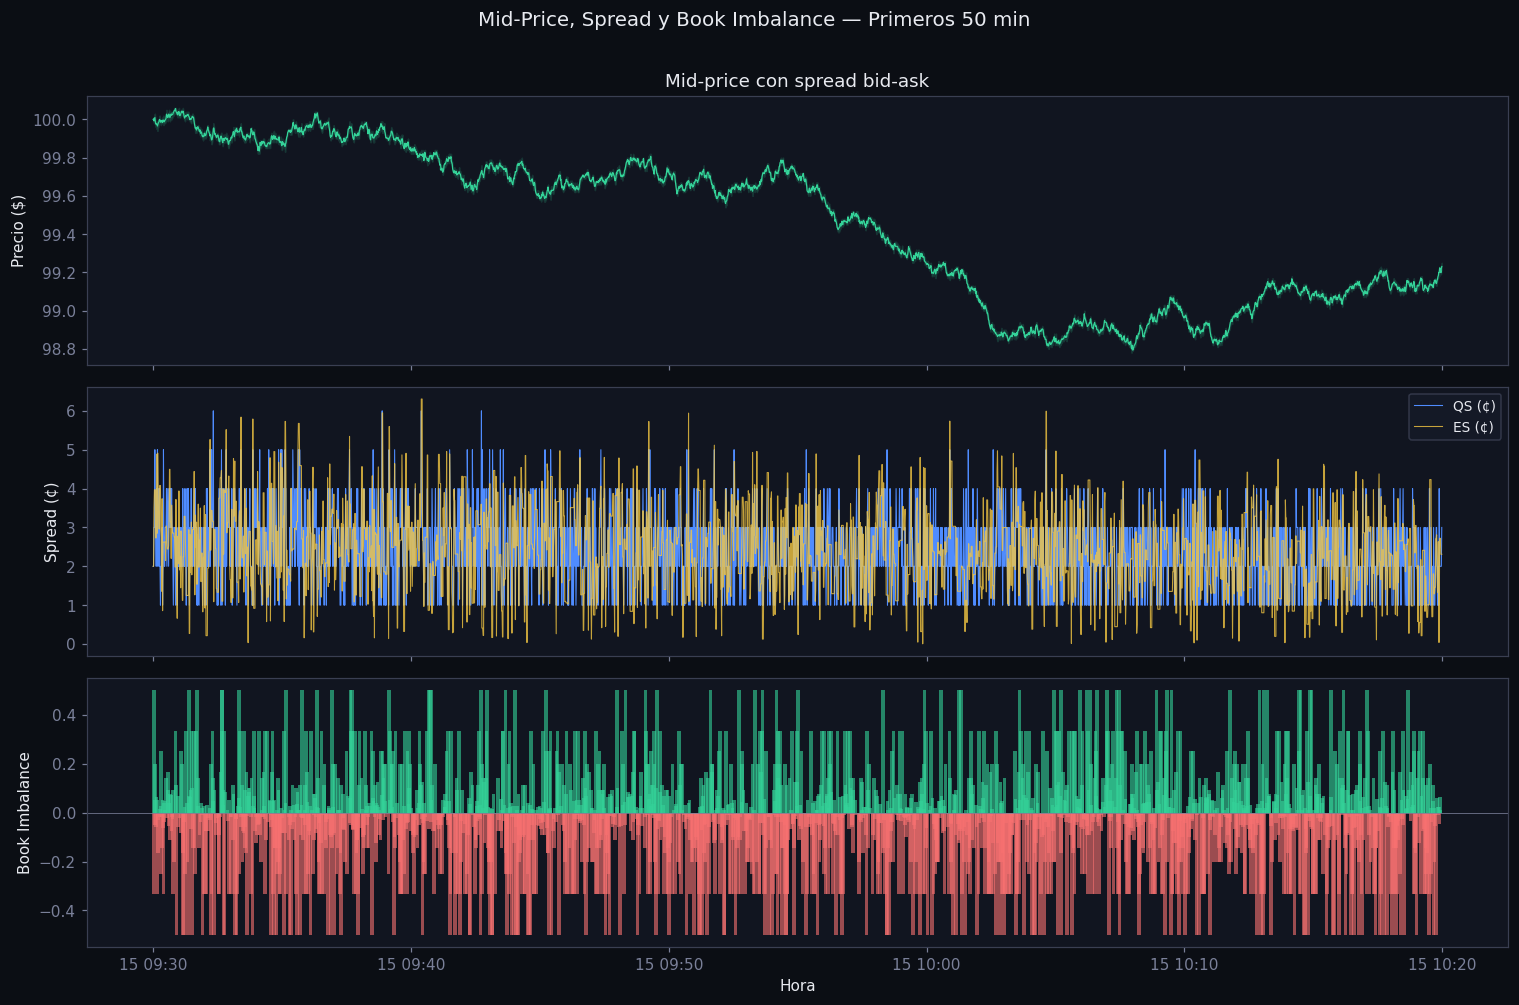

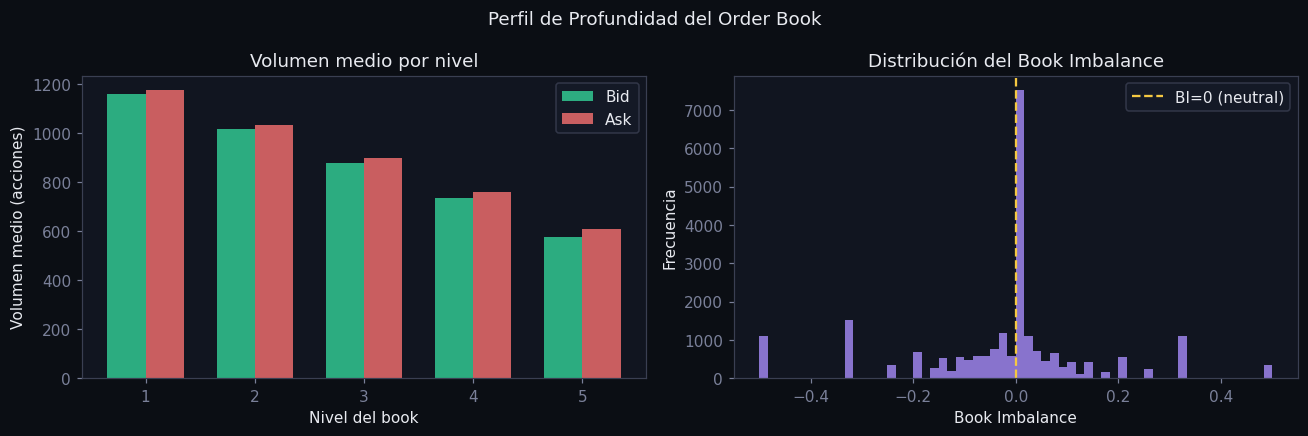

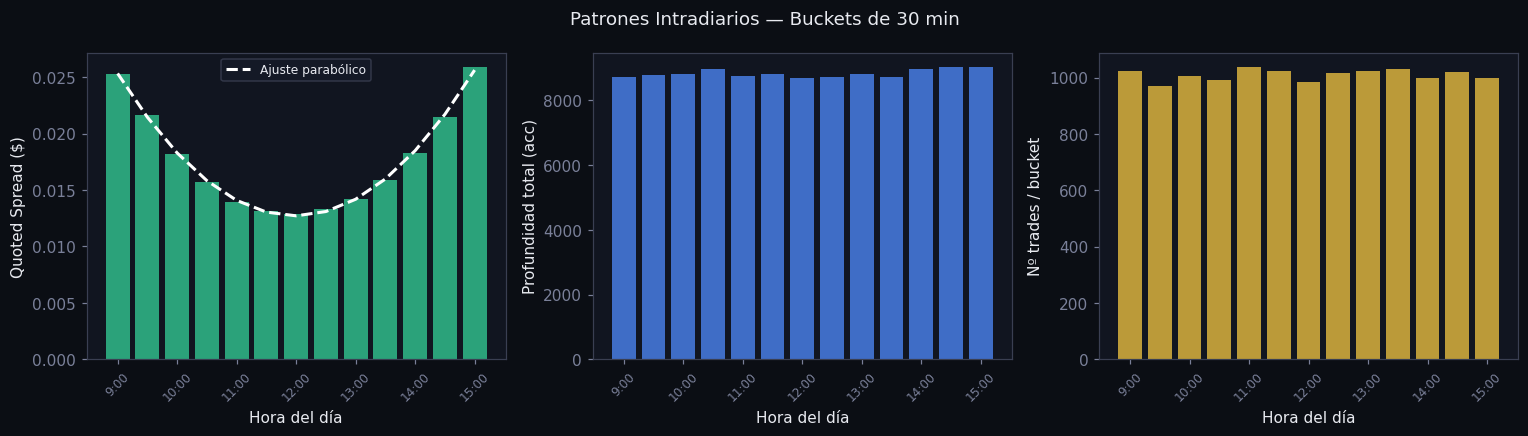

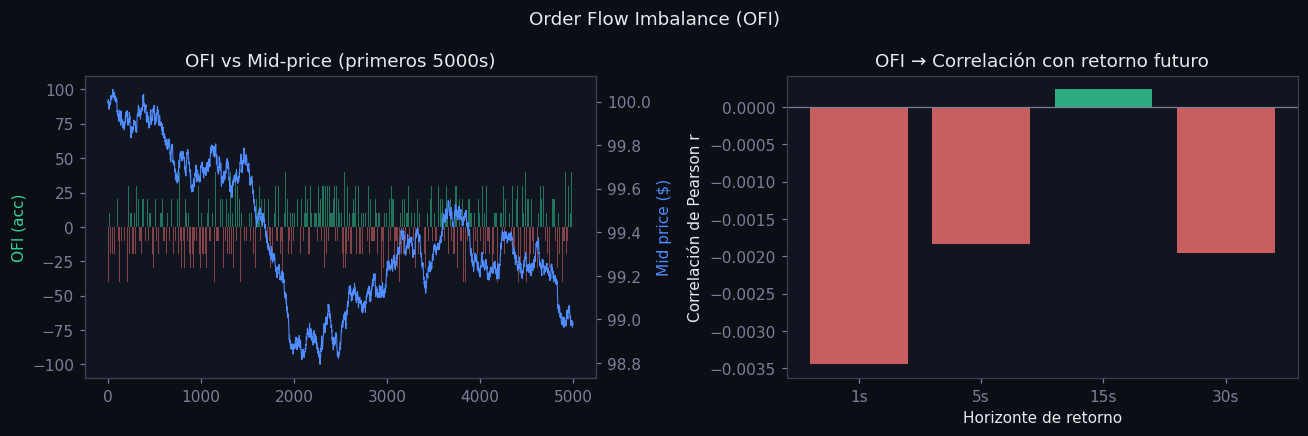

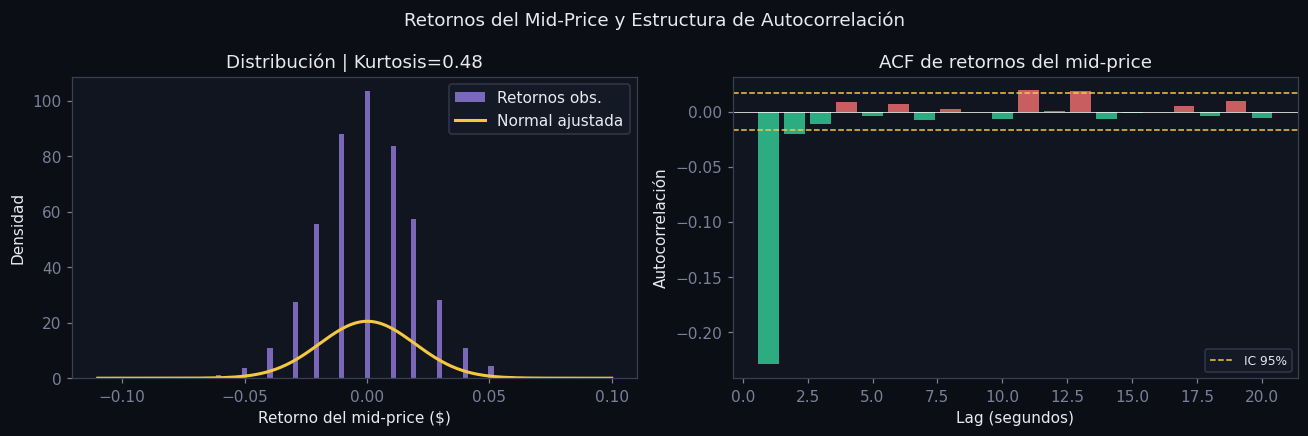

✓ 5 figuras generadas y guardadas


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 10 — Visualizaciones (5 figuras)
# ─────────────────────────────────────────────────────────────────────────────

sample = lob_clean.iloc[:3000]  # Primeras 50 min para gráficas de serie temporal

# ── Figura 1: Mid-price y spreads ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Mid-Price, Spread y Book Imbalance — Primeros 50 min', fontsize=13, y=1.01)

ax = axes[0]
ax.plot(sample.index, sample['mid_price'], color=COLORS['teal'], lw=0.8)
ax.fill_between(sample.index, sample['bid_1'], sample['ask_1'], alpha=0.15, color=COLORS['teal'])
ax.set_ylabel('Precio ($)')
ax.set_title('Mid-price con spread bid-ask')

ax = axes[1]
ax.plot(sample.index, sample['quoted_spread'] * 100, color=COLORS['blue'], lw=0.7, label='QS (¢)')
ax.plot(sample.index, sample['effective_spread'].fillna(method='ffill') * 100,
        color=COLORS['gold'], lw=0.7, alpha=0.8, label='ES (¢)')
ax.set_ylabel('Spread (¢)')
ax.legend(fontsize=9)

ax = axes[2]
ax.bar(sample.index, sample['book_imbalance'],
       color=np.where(sample['book_imbalance'] > 0, COLORS['teal'], COLORS['red']),
       alpha=0.6, width=0.0001)
ax.axhline(0, color=COLORS['muted'], lw=0.5)
ax.set_ylabel('Book Imbalance')
ax.set_xlabel('Hora')

plt.tight_layout()
plt.savefig('fig1_midprice_spread.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Figura 2: Profundidad por nivel ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Perfil de Profundidad del Order Book', fontsize=12)

ax = axes[0]
levels = range(1, N_LEVELS+1)
width  = 0.35
ax.bar([l - width/2 for l in levels], depth_by_level['bid_depth'],
       width, color=COLORS['teal'], alpha=0.8, label='Bid')
ax.bar([l + width/2 for l in levels], depth_by_level['ask_depth'],
       width, color=COLORS['red'], alpha=0.8, label='Ask')
ax.set_xlabel('Nivel del book')
ax.set_ylabel('Volumen medio (acciones)')
ax.set_xticks(levels)
ax.legend()
ax.set_title('Volumen medio por nivel')

ax = axes[1]
ax.hist(lob_clean['book_imbalance'].dropna(), bins=60,
        color=COLORS['purple'], edgecolor='none', alpha=0.8)
ax.axvline(0, color=COLORS['gold'], lw=1.5, ls='--', label='BI=0 (neutral)')
ax.set_xlabel('Book Imbalance')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del Book Imbalance')
ax.legend()

plt.tight_layout()
plt.savefig('fig2_depth_imbalance.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Figura 3: Patrones intradiarios (U-shape) ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Patrones Intradiarios — Buckets de 30 min', fontsize=12)

for ax, (col, label, color) in zip(axes, [
    ('qs_mean', 'Quoted Spread ($)', COLORS['teal']),
    ('vol_mean', 'Profundidad total (acc)', COLORS['blue']),
    ('n_trades', 'Nº trades / bucket', COLORS['gold']),
]):
    ax.bar(intraday.index, intraday[col], color=color, alpha=0.75, edgecolor='none')
    if col == 'qs_mean':
        ax.plot(intraday.index, spread_fitted, color='white', lw=2, ls='--', label='Ajuste parabólico')
        ax.legend(fontsize=8)
    ax.set_xticks(intraday.index[::2])
    ax.set_xticklabels(intraday['time_label'].iloc[::2], rotation=45, fontsize=8)
    ax.set_ylabel(label)
    ax.set_xlabel('Hora del día')

plt.tight_layout()
plt.savefig('fig3_intraday_patterns.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Figura 4: OFI y correlación con retornos ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Order Flow Imbalance (OFI)', fontsize=12)

ax = axes[0]
ofi_sample = lob_clean['OFI_smooth'].iloc[:5000]
mid_sample  = lob_clean['mid_price'].iloc[:5000]
ax2_twin = ax.twinx()
ax.bar(range(len(ofi_sample)), ofi_sample,
       color=np.where(ofi_sample > 0, COLORS['teal'], COLORS['red']),
       alpha=0.5, width=1)
ax2_twin.plot(range(len(mid_sample)), mid_sample, color=COLORS['blue'], lw=0.7)
ax.set_ylabel('OFI (acc)', color=COLORS['teal'])
ax2_twin.set_ylabel('Mid price ($)', color=COLORS['blue'])
ax.set_title('OFI vs Mid-price (primeros 5000s)')

ax = axes[1]
horizons_list  = list(corr_results.keys())
corr_vals  = [corr_results[h]['r'] for h in horizons_list]
colors_bar = [COLORS['teal'] if r > 0 else COLORS['red'] for r in corr_vals]
ax.bar([f'{h}s' for h in horizons_list], corr_vals, color=colors_bar, alpha=0.8)
ax.axhline(0, color=COLORS['muted'], lw=0.8)
ax.set_ylabel('Correlación de Pearson r')
ax.set_xlabel('Horizonte de retorno')
ax.set_title('OFI → Correlación con retorno futuro')

plt.tight_layout()
plt.savefig('fig4_ofi_correlation.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Figura 5: Distribución de retornos y autocorrelaciones ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Retornos del Mid-Price y Estructura de Autocorrelación', fontsize=12)

ax = axes[0]
ret_clean = mid_ret.dropna()
ax.hist(ret_clean, bins=100, density=True, color=COLORS['purple'], alpha=0.7, label='Retornos obs.')
x_range = np.linspace(ret_clean.min(), ret_clean.max(), 200)
normal_fit = stats.norm.pdf(x_range, ret_clean.mean(), ret_clean.std())
ax.plot(x_range, normal_fit, color=COLORS['gold'], lw=2, label='Normal ajustada')
ax.set_xlabel('Retorno del mid-price ($)')
ax.set_ylabel('Densidad')
ax.set_title(f'Distribución | Kurtosis={ret_clean.kurtosis():.2f}')
ax.legend()

ax = axes[1]
lags_range = range(1, 21)
colors_ac = [COLORS['teal'] if ac < 0 else COLORS['red'] for ac in acf_vals]
ax.bar(lags_range, acf_vals, color=colors_ac, alpha=0.8)
ax.axhline(0, color='white', lw=0.5)
# Banda de confianza 95% para ruido blanco
ci = 1.96 / np.sqrt(len(valid_ret))
ax.axhline(ci, color=COLORS['gold'], lw=1, ls='--', label='IC 95%')
ax.axhline(-ci, color=COLORS['gold'], lw=1, ls='--')
ax.set_xlabel('Lag (segundos)')
ax.set_ylabel('Autocorrelación')
ax.set_title('ACF de retornos del mid-price')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig5_returns_acf.png', dpi=110, bbox_inches='tight')
plt.show()

print('✓ 5 figuras generadas y guardadas')

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 11 — Resumen estadístico y exportación
# ─────────────────────────────────────────────────────────────────────────────

# ── Resumen consolidado ───────────────────────────────────────────────────────
summary = {
    'n_snapshots'           : len(lob_clean),
    'quoted_spread_mean'    : lob_clean['quoted_spread'].mean(),
    'quoted_spread_std'     : lob_clean['quoted_spread'].std(),
    'quoted_spread_bps_mean': lob_clean['quoted_spread_bps'].mean(),
    'effective_spread_mean' : lob_clean['effective_spread'].mean(),
    'effective_spread_bps'  : lob_clean['effective_spread_bps'].mean(),
    'ratio_es_qs'           : lob_clean['effective_spread'].mean() / lob_clean['quoted_spread'].mean(),
    'book_imbalance_mean'   : lob_clean['book_imbalance'].mean(),
    'OFI_mean'              : lob_clean['OFI'].mean(),
    'OFI_ret5s_corr'        : corr_results[5]['r'],
    'OFI_beta_OLS'          : ols_model.params['OFI'],
    'OFI_R2'                : ols_model.rsquared,
    'roll_spread'           : roll_spread,
    'adverse_selection_pct' : as_pct,
    'inventory_cost_pct'    : inv_pct,
    'ushape_R2_parabolic'   : R2_parab,
    'ushape_quad_coef'      : coef[0],
    'ks_stat_lognormal'     : ks_stat,
    'ks_pval_lognormal'     : ks_pval,
    'mid_price_final'       : lob_clean['mid_price'].iloc[-1],
    'mid_price_return_total': (lob_clean['mid_price'].iloc[-1] / S0 - 1) * 100,
}

summary_df = pd.DataFrame([summary]).T.rename(columns={0: 'valor'})
summary_df['valor'] = summary_df['valor'].round(6)

# ── Exportar archivos ────────────────────────────────────────────────────────
summary_df.to_csv('microestructura_summary.csv')

# Parquet con LOB limpio (columnas principales)
cols_export = (['mid_price', 'quoted_spread', 'quoted_spread_bps',
                'effective_spread', 'book_imbalance', 'OFI', 'OFI_norm',
                'trade_direction', 'total_bid_depth', 'total_ask_depth'] +
               [f'bid_{k}' for k in range(1, 6)] +
               [f'ask_{k}' for k in range(1, 6)] +
               [f'bid_vol_{k}' for k in range(1, 6)] +
               [f'ask_vol_{k}' for k in range(1, 6)])

lob_clean[cols_export].to_parquet('lob_clean.parquet', index=True)

print('✓ Exportados:')
print('  microestructura_summary.csv')
print('  lob_clean.parquet')
print('  fig1_midprice_spread.png  ... fig5_returns_acf.png')
print('\n═'*28)
print('RESUMEN FINAL DEL ANÁLISIS')
print('═'*28)
print(summary_df.to_string())

✓ Exportados:
  microestructura_summary.csv
  lob_clean.parquet
  fig1_midprice_spread.png  ... fig5_returns_acf.png

═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
═
RESUMEN FINAL DEL ANÁLISIS
════════════════════════════
                               valor
n_snapshots             23400.000000
quoted_spread_mean          0.017671
quoted_spread_std           0.008340
quoted_spread_bps_mean      1.774548
effective_spread_mean       0.017594
effective_spread_bps        1.766972
ratio_es_qs                 0.995665
book_imbalance_mean        -0.026924
OFI_mean                   -0.004274
OFI_ret5s_corr             -0.001841
OFI_beta_OLS               -0.000000
OFI_R2                      0.000003
roll_spread                 0.018647
adverse_selection_pct       0.000000
inventory_cost_pct        105.525307
ushape_R2_parabolic         0.998807
ushape_quad_coef            0.051048
ks_stat_lognormal           0.166728
ks_pval_lognormal           0.000000
mid_price_final           101.